# Assignment 8 - MSL Recognition
This assignement is prepared by Aung Hein. [MSL4Emergency](https://github.com/ye-kyaw-thu/MSL4Emergency) Dataset was used.

**Corpus Link:** [https://github.com/ye-kyaw-thu/MSL4Emergency](https://github.com/ye-kyaw-thu/MSL4Emergency)  

### Dataset Preparation

In [1]:
%%bash
rm -rf .git
git init -q

git remote add -f origin https://github.com/thonenyangal/AIE-F.git

git config core.sparseCheckout true
echo "slide-code/class-25/msl_recognition/*" >> .git/info/sparse-checkout

git pull origin main

mv slide-code/class-25/msl_recognition/src ./
mv slide-code/class-25/msl_recognition/scripts ./
mv slide-code/class-25/msl_recognition/tools ./
mv slide-code/class-25/msl_recognition/data ./
mv slide-code/class-25/msl_recognition/src/models ./
rm -rf slide-code
rm -rf .git

Updating origin


From https://github.com/thonenyangal/AIE-F
 * [new branch]        main       -> origin/main
From https://github.com/thonenyangal/AIE-F
 * branch              main       -> FETCH_HEAD
mv: cannot move 'slide-code/class-25/msl_recognition/src' to './src': Directory not empty
mv: cannot move 'slide-code/class-25/msl_recognition/scripts' to './scripts': Directory not empty
mv: cannot move 'slide-code/class-25/msl_recognition/tools' to './tools': Directory not empty
mv: cannot move 'slide-code/class-25/msl_recognition/data' to './data': Directory not empty
mv: cannot move 'slide-code/class-25/msl_recognition/src/models' to './models': Directory not empty


In [2]:
!cp -r ../input/datasets/thonenyangal/ye-kyaw-thu-msl4emergency/msl4emergency-ver-1.0/* data

In [3]:
!chmod +x scripts/*.sh

In [4]:
!ls -la data

total 780
drwxr-xr-x  4 root root   4096 Jun 14 01:32 .
drwxr-xr-x  8 root root   4096 Jun 14 01:32 ..
-rw-r--r--  1 root root  94545 Jun 14 01:26 annotations.txt
drwxr-xr-x  3 root root   4096 Jun 14 01:32 elan-and-pfsx
-rw-r--r--  1 root root  51110 Jun 14 01:32 my
-rw-r--r--  1 root root 117978 Jun 14 01:32 my-mypos
-rw-r--r--  1 root root  66868 Jun 14 01:32 my-pos
-rw-r--r--  1 root root  94545 Jun 14 01:32 my-sl
-rw-r--r--  1 root root    833 Jun 14 01:32 note.txt
-rw-r--r--  1 root root 196415 Jun 14 01:32 SignWriting.pdf
-rw-r--r--  1 root root  93467 Jun 14 01:32 SignWriting.txt
-rw-r--r--  1 root root  43435 Jun 14 01:32 sl
-rw-r--r--  1 root root      1 Jun 14 01:26 tmp
drwxr-xr-x 13 root root   4096 Jun 14 01:33 video


In [5]:
!mv data/video data/videos

In [6]:
!mkdir -p config

In [7]:
%%writefile requirements.txt
# Myanmar Sign Language Recognition - Dependencies
# Python >= 3.9 recommended
# PyTorch with CUDA 11.8+ (for RTX 3090 Ti)

# Core deep learning
torch>=2.1.0
torchvision>=0.16.0
torchaudio>=2.1.0

# MediaPipe for keypoint extraction
mediapipe==0.10.18

# Computer vision
opencv-python>=4.8.0

# Scientific computing
numpy>=1.24.0
scipy>=1.11.0
scikit-learn>=1.3.0

# Data handling
pandas>=2.0.0
PyYAML>=6.0

# Visualization
matplotlib>=3.7.0
seaborn>=0.13.0

# Progress bars
tqdm>=4.66.0

# Experiment tracking
tensorboard>=2.14.0

# Metrics
torchmetrics>=1.2.0

# Optional: Weights & Biases (uncomment if desired)
# wandb>=0.16.0

Writing requirements.txt


In [8]:
%%writefile config/config.yaml
# ============================================================
# Myanmar Sign Language Recognition - Configuration
# ============================================================

data:
  video_dir: "data/videos"
  keypoint_dir: "data/keypoints"
  augmented_dir: "data/augmented"
  annotation_file: "data/annotations.txt"
  label_map_file: "data/label_map.json"
  split_file: "data/splits.json"

  # MediaPipe feature dimensions
  pose_landmarks: 33          # 33 body landmarks
  hand_landmarks: 21          # 21 landmarks per hand
  num_nodes: 75               # 33 + 21 + 21
  coord_dim: 3                # x, y, z
  feature_dim: 225            # 75 * 3 (flattened per frame)

  max_seq_len: 200            # Maximum frames (videos longer are trimmed)
  min_seq_len: 5              # Minimum frames (shorter are skipped)

  # Data split
  test_ratio: 0.15
  val_ratio: 0.15
  n_folds: 5                  # For cross-validation experiments
  seed: 42

augmentation:
  enabled: true
  aug_factor: 20              # Generate 20x samples from training set
  save_format: "npy"

  # Individual augmentation probabilities & parameters
  gaussian_noise:
    prob: 0.7
    std: 0.008
  time_warp:
    prob: 0.6
    sigma: 0.15               # Controls warp intensity
    knot: 4                   # Number of warp control points
  horizontal_flip:
    prob: 0.5                 # Mirror along vertical axis
  speed_perturbation:
    prob: 0.6
    min_factor: 0.75
    max_factor: 1.35
  frame_dropout:
    prob: 0.4
    max_drop_ratio: 0.1
  spatial_rotate:
    prob: 0.5
    max_angle: 12             # degrees
  joint_mask:
    prob: 0.3
    max_mask_ratio: 0.1       # Randomly zero-out some joints
  scale_jitter:
    prob: 0.4
    min_scale: 0.85
    max_scale: 1.15
  temporal_shift:
    prob: 0.3
    max_shift: 5              # frames

training:
  batch_size: 32
  num_epochs: 150
  learning_rate: 0.0005
  weight_decay: 0.0001
  warmup_epochs: 10
  patience: 25                # early stopping patience
  label_smoothing: 0.1
  num_workers: 8
  pin_memory: true
  use_amp: true               # Automatic Mixed Precision (for RTX 3090 Ti)
  grad_clip: 1.0
  seed: 42
  save_top_k: 3               # Save top k checkpoints

  # Learning rate scheduler
  scheduler: "cosine"         # "cosine" | "step" | "plateau"
  cosine_T_max: 150
  cosine_eta_min: 0.000005

  # Loss
  loss: "cross_entropy"       # "cross_entropy" | "focal"
  focal_gamma: 2.0

model:
  bilstm:
    input_dim: 225
    hidden_dim: 256
    num_layers: 3
    dropout: 0.4
    bidirectional: true
    use_attention: true
    attention_type: "additive" # "dot" | "additive"

  transformer:
    input_dim: 225
    d_model: 256
    nhead: 8
    num_encoder_layers: 4
    dim_feedforward: 1024
    dropout: 0.1
    max_seq_len: 210
    use_cls_token: true

  stgcn:
    in_channels: 3            # x, y, z
    num_nodes: 75             # 33 pose + 21 left_hand + 21 right_hand
    edge_importance_weighting: true
    temporal_kernel_size: 9
    dropout: 0.3
    # Channel progression for ST-GCN blocks
    graph_cfg:
      layout: "msl_holistic"
      strategy: "spatial"

evaluation:
  metrics:
    - "accuracy_top1"
    - "accuracy_top5"
    - "precision_macro"
    - "recall_macro"
    - "f1_macro"
    - "confusion_matrix"
  output_dir: "results"
  plot_confusion_matrix: true
  save_predictions: true

logging:
  log_dir: "results/logs"
  log_interval: 10            # Log every N batches
  use_tensorboard: true


Writing config/config.yaml


In [9]:
!python --version

Python 3.12.13


In [10]:
%%writefile scripts/00_setup_env.sh
#!/usr/bin/env bash
# =============================================================================
# 00_setup_env.sh  –  Create venv and install all dependencies
# =============================================================================
# Usage: bash scripts/00_setup_env.sh
# =============================================================================

set -euo pipefail

ENV_NAME="msl_recog"
VENV_DIR=".venv"
PYTHON_VERSION="3.12.13"

echo "============================================================"
echo " MSL Recognition — Environment Setup"
echo "============================================================"

# ── Upgrade pip ──────────────────────────────────────────────────────────────
echo "[INFO] Upgrading pip…"
pip install --upgrade pip

# ── PyTorch (CUDA 11.8 for RTX 3090 Ti) ─────────────────────────────────────
echo "[INFO] Installing PyTorch with CUDA support…"
pip install torch torchvision torchaudio \
    --index-url https://download.pytorch.org/whl/cu118

# ── Other dependencies ───────────────────────────────────────────────────────
echo "[INFO] Installing remaining dependencies…"
pip install -r requirements.txt

# ── Verify GPU ───────────────────────────────────────────────────────────────
echo ""
echo "[CHECK] GPU detection:"
python -c "
import torch
print(f'  CUDA available : {torch.cuda.is_available()}')
print(f'  Device count   : {torch.cuda.device_count()}')
if torch.cuda.is_available():
    print(f'  GPU name       : {torch.cuda.get_device_name(0)}')
    mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'  GPU memory     : {mem:.1f} GB')
"

echo ""
echo "[CHECK] MediaPipe:"
python -c "import mediapipe; print(f'  mediapipe {mediapipe.__version__} OK')"

echo ""
echo "============================================================"
echo " Setup complete!  Activate with:"
echo "   source ${VENV_DIR}/bin/activate"
echo "============================================================"

Overwriting scripts/00_setup_env.sh


In [11]:
!time scripts/00_setup_env.sh

 MSL Recognition — Environment Setup
[INFO] Upgrading pip…
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 66.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
[INFO] Installing PyTorch with CUDA support…
Looking in indexes: https://download.pytorch.org/whl/cu118
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 108.6 MB/s  0:00:000:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 37.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 122.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 52.3 MB/s  0:00:06:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 45.5 MB/s  0:00:06:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16

In [12]:
!head data/annotations.txt

မီး ။	မီး
မီး ငြှိမ်း ။	မီး ငြှိမ်း
မီးချိတ် ။	မီးချိတ်
မီးကပ် ။	မီးကပ်
ရေပုံး ။	ရေပုံး
သဲ အိတ် ။	အိတ် ထဲ သဲ
မီးသတ်ဆေးဘူး ။	အနီ ဘူး ဖြန်း
မီးသတ်ရေကန် ။	ကန် ထဲ ရေ သိမ်း
မီးလောင် လွယ် သော ပစ္စည်း များ ။	မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး
လောင်စာဆီ ။	ဓာတ်ဆီ 9 2 9 5 အောက်တိန်း အမျိုးမျိုး


Since our assignment was to training with label msl_gloss, i have to edit a bit in utils.py as below

In [13]:
!sed -i "s/'label':[[:space:]]*normal_text/'label':       msl_gloss/g" src/utils.py

In [14]:
!time scripts/01_prepare_data.sh

 Step 1 — Data Preparation
 Video dir       : data/videos
 Annotation file : data/annotations.txt

 Found 558 videos and 558 annotation lines

2026-06-14 01:36:31 | INFO     | prepare_data | ============================================================
2026-06-14 01:36:31 | INFO     | prepare_data | MSL Data Preparation
2026-06-14 01:36:31 | INFO     | prepare_data | ============================================================
2026-06-14 01:36:31 | INFO     | prepare_data | Parsing annotation file: data/annotations.txt
2026-06-14 01:36:31 | INFO     | prepare_data | Total annotation records: 558
2026-06-14 01:36:31 | INFO     | prepare_data | Vocabulary built: 541 unique classes
2026-06-14 01:36:31 | INFO     | prepare_data | Label map saved → data/label_map.json
2026-06-14 01:36:31 | INFO     | prepare_data | Matching videos from: data/videos
2026-06-14 01:36:31 | INFO     | prepare_data | NOTE: MSL4Emergency has ~1 video per sign class. The pipeline handles this via: (1) random (non-s

In [15]:
!head data/label_map.json

{
  "label2idx": {
    "မီး": 0,
    "မီး ငြှိမ်း": 1,
    "မီးချိတ်": 2,
    "မီးကပ်": 3,
    "ရေပုံး": 4,
    "အိတ် ထဲ သဲ": 5,
    "အနီ ဘူး ဖြန်း": 6,
    "ကန် ထဲ ရေ သိမ်း": 7,


In [16]:
!time scripts/02_extract_keypoints.sh

 Step 2 — MediaPipe Holistic Keypoint Extraction
 Video dir     : data/videos
 Output dir    : data/keypoints
 Complexity    : 2
 Overwrite     : false

 Total videos  : 558

2026-06-14 01:36:33.789727: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781400993.811429     345 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781400993.818623     345 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781400993.836732     345 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781400993.836773     345 computation_placer.cc:177] computation placer alr

In [17]:
!cat ./data/keypoints/extraction_stats.json

{
  "total": 558,
  "processed": 558,
  "failed": 0,
  "skipped": 0,
  "seq_len_min": 50,
  "seq_len_max": 387,
  "seq_len_mean": 130.56810035842295,
  "seq_len_std": 55.11924044288601,
  "seq_len_p50": 119.0,
  "seq_len_p95": 241.14999999999998,
  "lh_mean_presence": 0.6177208780096964,
  "rh_mean_presence": 0.7129535191739758
}

In [18]:
!time scripts/03_augment_data.sh

 Step 3 — All-Class Offline Data Augmentation
 Strategy    : all 558 videos → train/val/test by aug type
 Aug factor  : 20x
   Train     : 19 aug copies × 558 = 10602 samples
   Val       : 1 aug copy × 558 = 558 samples
   Test      : 558 originals (no augmentation)
 Class overlap: 100% across all splits

Augmenting all classes: 100%|██████████| 558/558 [00:33<00:00, 16.59sign/s]

  Augmentation Complete (all-class design)
  Original videos   : 558
  Aug factor        : 20  (train uses 19, val uses 1)
  Train samples     : 10602  (augmented, all classes)
  Val   samples     : 558   (augmented, all classes)
  Test  samples     : 558   (original,  all classes)
  Class overlap     : 100% across all splits
  Manifest          : data/augmented/augmented_manifest.json


 Augmentation done!  Manifest → data/augmented/augmented_manifest.json
 Next: bash scripts/04_train.sh

real	0m37.123s
user	0m35.578s
sys	0m2.286s


In [19]:
!tail -n 30 data/augmented/augmented_manifest.json

      "normal_text": "သူမ သတိ လစ် နေ တာ လား ။",
      "msl_gloss": "သူ သတိလစ် နေတာလား",
      "label": "သူ သတိလစ် နေတာလား",
      "video_path": "data/videos/501-558/idx20-556.mp4",
      "keypoint_path": "data/keypoints/501-558/idx20-556.npy",
      "is_augmented": false,
      "split": "test"
    },
    {
      "idx": 556,
      "normal_text": "ဟင့်အင်း ၊ သတိ မ လစ် ပါ ဘူး ။",
      "msl_gloss": "သတိလစ် မဟုတ်ဘူး သတိ ရတယ်",
      "label": "သတိလစ် မဟုတ်ဘူး သတိ ရတယ်",
      "video_path": "data/videos/501-558/idx20-557.mp4",
      "keypoint_path": "data/keypoints/501-558/idx20-557.npy",
      "is_augmented": false,
      "split": "test"
    },
    {
      "idx": 557,
      "normal_text": "ဆရာဝန် ဘယ် အချိန် လာ မှာ လဲ ။",
      "msl_gloss": "ဆရာဝန် လာ အချိန် ဘယ်လောက်လဲ",
      "label": "ဆရာဝန် လာ အချိန် ဘယ်လောက်လဲ",
      "video_path": "data/videos/501-558/idx20-558.mp4",
      "keypoint_path": "data/keypoints/501-558/idx20-558.npy",
      "is_augmented": false,
      "split": "test"
    }
 

In [20]:
!ls ./data/augmented/val/* | head

./data/augmented/val/0000_aug000.npy
./data/augmented/val/0001_aug000.npy
./data/augmented/val/0002_aug000.npy
./data/augmented/val/0003_aug000.npy
./data/augmented/val/0004_aug000.npy
./data/augmented/val/0005_aug000.npy
./data/augmented/val/0006_aug000.npy
./data/augmented/val/0007_aug000.npy
./data/augmented/val/0008_aug000.npy
./data/augmented/val/0009_aug000.npy
ls: write error: Broken pipe


In [21]:
!ls ./data/augmented/train/* | head

./data/augmented/train/0000_aug001.npy
./data/augmented/train/0000_aug002.npy
./data/augmented/train/0000_aug003.npy
./data/augmented/train/0000_aug004.npy
./data/augmented/train/0000_aug005.npy
./data/augmented/train/0000_aug006.npy
./data/augmented/train/0000_aug007.npy
./data/augmented/train/0000_aug008.npy
./data/augmented/train/0000_aug009.npy
./data/augmented/train/0000_aug010.npy
ls: write error: Broken pipe


In [22]:
!ls -la src/

total 356
drwxr-xr-x  4 root root  4096 Jun 14 01:36 .
drwxr-xr-x 10 root root  4096 Jun 14 01:36 ..
-rw-r--r--  1 root root 14475 Jun 14 01:26 augment.py
-rw-r--r--  1 root root 14092 Jun 14 01:26 cross_validate.py
-rw-r--r--  1 root root  6981 Jun 14 01:26 dataset.py
-rw-r--r--  1 root root 14778 Jun 14 01:26 evaluate.py
-rw-r--r--  1 root root 22255 Jun 14 01:26 export_to_onnx.py
-rw-r--r--  1 root root 12666 Jun 14 01:26 extract_keypoints.py
-rw-r--r--  1 root root 51548 Jun 14 01:26 infer_onnx.py
-rw-r--r--  1 root root 48254 Jun 14 01:26 infer_onnx.py.6June.bk
-rw-r--r--  1 root root 33574 Jun 14 01:26 infer_onnx.py.err
-rw-r--r--  1 root root 14543 Jun 14 01:26 infer.py
-rw-r--r--  1 root root    52 Jun 14 01:26 __init__.py
drwxr-xr-x  2 root root  4096 Jun 14 01:26 models
-rw-r--r--  1 root root 17327 Jun 14 01:26 plot_results.py
-rw-r--r--  1 root root 15114 Jun 14 01:26 plot_results_v2.py
-rw-r--r--  1 root root  7558 Jun 14 01:26 prepare_data.py
drwxr-xr-x  2 root root  4096

In [23]:
# %%writefile /kaggle/working/src/models.py
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import math


# class AdditiveAttention(nn.Module):
#     def __init__(self, hidden_dim):
#         super().__init__()
#         self.W = nn.Linear(hidden_dim, hidden_dim)
#         self.v = nn.Linear(hidden_dim, 1, bias=False)

#     def forward(self, x, mask=None):
#         # x: (B, T, H), mask: (B, T), 1=True valid, 0=False padding
#         scores = self.v(torch.tanh(self.W(x)))  # (B, T, 1)

#         if mask is not None:
#             if mask.dim() == 2:
#                 mask = mask.unsqueeze(-1)
#             mask = mask.to(device=x.device)
#             scores = scores.masked_fill(mask == 0, -30000.0)

#         attn_weights = torch.softmax(scores, dim=1)
#         context = torch.sum(x * attn_weights, dim=1)
#         return context


# class BiLSTMModel(nn.Module):
#     """
#     Teacher-aligned BiLSTM:
#       input:       (B, T, 225)
#       core:        3-layer BiLSTM
#       aggregation: additive attention or masked mean
#       output:      raw logits
#     """
#     def __init__(self, mcfg, num_classes):
#         super().__init__()
#         input_dim = mcfg['input_dim']
#         hidden_dim = mcfg['hidden_dim']
#         num_layers = mcfg['num_layers']
#         dropout = mcfg['dropout']
#         bidirectional = mcfg['bidirectional']

#         self.lstm = nn.LSTM(
#             input_size=input_dim,
#             hidden_size=hidden_dim,
#             num_layers=num_layers,
#             batch_first=True,
#             dropout=dropout if num_layers > 1 else 0.0,
#             bidirectional=bidirectional,
#         )

#         out_dim = hidden_dim * 2 if bidirectional else hidden_dim
#         self.use_attention = mcfg.get('use_attention', True)

#         if self.use_attention:
#             self.attention = AdditiveAttention(out_dim)

#         self.fc = nn.Linear(out_dim, num_classes)

#     def forward(self, x, lengths=None, mask=None):
#         x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

#         lstm_out, _ = self.lstm(x)

#         if self.use_attention:
#             context = self.attention(lstm_out, mask)
#         else:
#             if mask is not None:
#                 mask_expanded = mask.to(device=lstm_out.device, dtype=lstm_out.dtype).unsqueeze(-1)
#                 context = (lstm_out * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1.0)
#             else:
#                 context = lstm_out.mean(dim=1)

#         return self.fc(context)


# class PositionalEncoding(nn.Module):
#     """
#     Sinusoidal positional encoding.
#     Used by teacher-style Transformer after prepending CLS token.
#     """
#     def __init__(self, d_model, max_len=300, dropout=0.1):
#         super().__init__()
#         self.dropout = nn.Dropout(p=dropout)

#         pe = torch.zeros(max_len, d_model)
#         position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
#         div_term = torch.exp(
#             torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
#         )

#         pe[:, 0::2] = torch.sin(position * div_term)
#         pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])

#         self.register_buffer('pe', pe.unsqueeze(0))

#     def forward(self, x):
#         # x: (B, T, D)
#         pe = self.pe[:, :x.size(1)].to(dtype=x.dtype, device=x.device)
#         return self.dropout(x + pe)


# class TransformerModel(nn.Module):
#     """
#     Teacher/Gemini-aligned CLS Transformer for MediaPipe keypoint video -> MSL_gloss.

#     Expected input from dataset/train.py:
#       x:    (B, T, 225) flattened MediaPipe landmarks
#       mask: (B, T), 1/True = valid frame, 0/False = padding

#     Pipeline:
#       (B,T,225) -> Linear(225,d_model) -> prepend CLS -> PE -> TransformerEncoder -> CLS -> logits

#     Notes:
#       - Keep attribute name `encoder` because train.py checks hasattr(model, 'encoder').
#       - forward signature supports mask/lengths/kwargs without requiring train.py changes.
#       - Return raw logits only. CrossEntropyLoss applies softmax internally.
#     """
#     def __init__(self, mcfg, num_classes):
#         super().__init__()
#         input_dim = mcfg['input_dim']
#         d_model = mcfg['d_model']
#         nhead = mcfg['nhead']
#         num_encoder_layers = mcfg['num_encoder_layers']
#         dim_feedforward = mcfg['dim_feedforward']
#         dropout = mcfg.get('dropout', 0.1)
#         max_seq_len = mcfg.get('max_seq_len', 210)

#         self.use_cls_token = mcfg.get('use_cls_token', True)
#         self.d_model = d_model

#         self.input_projection = nn.Linear(input_dim, d_model)
#         self.pos_encoder = PositionalEncoding(
#             d_model=d_model,
#             max_len=max_seq_len + 10,
#             dropout=dropout,
#         )

#         if self.use_cls_token:
#             self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=d_model,
#             nhead=nhead,
#             dim_feedforward=dim_feedforward,
#             dropout=dropout,
#             activation='relu',
#             batch_first=True,
#             norm_first=True,
#         )
#         self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
#         self.fc = nn.Linear(d_model, num_classes)

#     def _make_mask_from_lengths(self, lengths, seq_len, device):
#         arange = torch.arange(seq_len, device=device).unsqueeze(0)
#         return arange < lengths.to(device).unsqueeze(1)

#     def forward(self, x, mask=None, lengths=None, **kwargs):
#         x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
#         B, S, _ = x.shape

#         # Be robust to either mask or lengths.
#         if mask is None and lengths is not None:
#             if lengths.dim() == 2:
#                 mask = lengths
#             else:
#                 mask = self._make_mask_from_lengths(lengths, S, x.device)

#         if mask is not None and mask.dim() == 1:
#             mask = self._make_mask_from_lengths(mask, S, x.device)
#         elif mask is not None and mask.dim() == 3:
#             mask = mask.squeeze(-1)

#         src_key_padding_mask = None
#         if mask is not None:
#             # PyTorch Transformer expects True for padded/ignored positions.
#             src_key_padding_mask = (mask == 0).to(device=x.device, dtype=torch.bool)

#         # Linear projection: 225 -> d_model
#         x = self.input_projection(x)

#         # Prepend CLS token, then apply positional encoding over CLS + frames.
#         if self.use_cls_token:
#             cls_tokens = self.cls_token.expand(B, 1, -1)
#             x = torch.cat((cls_tokens, x), dim=1)

#             if src_key_padding_mask is not None:
#                 cls_mask = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
#                 src_key_padding_mask = torch.cat((cls_mask, src_key_padding_mask), dim=1)

#         x = self.pos_encoder(x)
#         out = self.encoder(x, src_key_padding_mask=src_key_padding_mask)

#         if self.use_cls_token:
#             feat = out[:, 0]
#         else:
#             if src_key_padding_mask is not None:
#                 valid = (~src_key_padding_mask).to(dtype=out.dtype, device=out.device).unsqueeze(-1)
#                 feat = (out * valid).sum(dim=1) / valid.sum(dim=1).clamp(min=1.0)
#             else:
#                 feat = out.mean(dim=1)

#         return self.fc(feat)


# class STGCNBlock(nn.Module):
#     """
#     Basic ST-GCN block.
#     Input/Output format: (B, C, T, V)
#     """
#     def __init__(self, in_channels, out_channels, num_nodes, kernel_size=9, stride=1, dropout=0.3):
#         super().__init__()

#         self.gcn = nn.Conv2d(in_channels, out_channels, kernel_size=1)

#         # Learnable adjacency matrix. Starts near identity.
#         self.A = nn.Parameter(torch.eye(num_nodes) + torch.randn(num_nodes, num_nodes) * 0.01)

#         padding = (kernel_size - 1) // 2
#         self.tcn = nn.Sequential(
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(
#                 out_channels,
#                 out_channels,
#                 kernel_size=(kernel_size, 1),
#                 stride=(stride, 1),
#                 padding=(padding, 0),
#             ),
#             nn.BatchNorm2d(out_channels),
#             nn.Dropout(dropout, inplace=True),
#         )

#         if in_channels == out_channels and stride == 1:
#             self.residual = nn.Identity()
#         else:
#             self.residual = nn.Sequential(
#                 nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride, 1)),
#                 nn.BatchNorm2d(out_channels),
#             )

#         self.relu = nn.ReLU(inplace=True)

#     def forward(self, x):
#         # x: (B, C, T, V)
#         res = self.residual(x)
#         x_gcn = torch.einsum('bctv,vw->bctw', x, self.A)
#         x_gcn = self.gcn(x_gcn)
#         return self.relu(self.tcn(x_gcn) + res)


# class STGCNModel(nn.Module):
#     """
#     Teacher-aligned ST-GCN:
#       input shape: T x 3 x 75 graph structure preserved
#       blocks:      3 -> 64 -> 64 -> 128 -> 256
#       pooling:     global temporal + node pooling
#       output:      raw logits

#     Supports dataset outputs:
#       - (B, T, 225)
#       - (B, T, 3, 75)
#       - (B, 3, T, 75)
#       - (B, T, 75, 3)
#     Converts all to channel-first (B, 3, T, 75).
#     """
#     def __init__(self, mcfg, num_classes):
#         super().__init__()
#         in_channels = mcfg['in_channels']
#         self.num_nodes = mcfg['num_nodes']
#         kernel_size = mcfg.get('temporal_kernel_size', 9)
#         dropout = mcfg.get('dropout', 0.3)

#         self.block1 = STGCNBlock(in_channels, 64, self.num_nodes, kernel_size=kernel_size, stride=1, dropout=dropout)
#         self.block2 = STGCNBlock(64, 64, self.num_nodes, kernel_size=kernel_size, stride=1, dropout=dropout)
#         self.block3 = STGCNBlock(64, 128, self.num_nodes, kernel_size=kernel_size, stride=2, dropout=dropout)
#         self.block4 = STGCNBlock(128, 256, self.num_nodes, kernel_size=kernel_size, stride=2, dropout=dropout)
#         self.fc = nn.Linear(256, num_classes)

#     def _to_bctv(self, x):
#         """Convert supported keypoint tensor layouts to (B, 3, T, V)."""
#         if x.dim() == 3:
#             # Flattened sequence: (B, T, 225)
#             B, T, feat_dim = x.shape
#             expected_dim = 3 * self.num_nodes
#             if feat_dim != expected_dim:
#                 raise ValueError(
#                     f'ST-GCN expected feature dim {expected_dim}, got {feat_dim}. Shape={tuple(x.shape)}'
#                 )
#             return x.view(B, T, 3, self.num_nodes).permute(0, 2, 1, 3).contiguous()

#         if x.dim() == 4:
#             # Already channel-first: (B, 3, T, V)
#             if x.size(1) == 3 and x.size(3) == self.num_nodes:
#                 return x.contiguous()

#             # Teacher graph shape: (B, T, 3, V)
#             if x.size(2) == 3 and x.size(3) == self.num_nodes:
#                 return x.permute(0, 2, 1, 3).contiguous()

#             # Alternative: (B, T, V, 3)
#             if x.size(2) == self.num_nodes and x.size(3) == 3:
#                 return x.permute(0, 3, 1, 2).contiguous()

#             raise ValueError(
#                 f'Unsupported ST-GCN 4D input shape {tuple(x.shape)}. Expected '
#                 f'(B,3,T,{self.num_nodes}), (B,T,3,{self.num_nodes}), or (B,T,{self.num_nodes},3).'
#             )

#         raise ValueError(f'Unsupported ST-GCN input dim={x.dim()}, shape={tuple(x.shape)}')

#     def forward(self, x, mask=None, lengths=None, **kwargs):
#         x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
#         x = self._to_bctv(x)

#         x = self.block1(x)
#         x = self.block2(x)
#         x = self.block3(x)
#         x = self.block4(x)

#         x = F.adaptive_avg_pool2d(x, (1, 1)).view(x.size(0), -1)
#         return self.fc(x)


# def build_model(model_type, cfg, num_classes):
#     mcfg = cfg['model'][model_type]

#     if model_type == 'bilstm':
#         return BiLSTMModel(mcfg, num_classes)
#     elif model_type == 'transformer':
#         return TransformerModel(mcfg, num_classes)
#     elif model_type == 'stgcn':
#         return STGCNModel(mcfg, num_classes)
#     else:
#         raise ValueError(f'Unknown model type: {model_type}')

### Exp1 - BiLSTM Model

In [24]:
!time bash scripts/04_train.sh bilstm exp1_bilstm

 Training MSL Recognition Model
 Model      : bilstm
 Experiment : exp1_bilstm
 Config     : config/config.yaml

 Data: train=10602, val=558, test=558 (all-class design)

[GPU]
Tesla T4, 15360 MiB, 14913 MiB, 35
Tesla T4, 15360 MiB, 14913 MiB, 34

2026-06-14 03:48:58.758150: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781408938.780588    2657 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781408938.788206    2657 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781408938.807026    2657 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:17

In [25]:
!time bash scripts/05_evaluate.sh bilstm exp1_bilstm

 Evaluation — bilstm / exp1_bilstm
 Checkpoint : results/exp1_bilstm/checkpoints/best.pth
 Output dir : results/exp1_bilstm/evaluation

── Validation set ──────────────────────────────────────────
2026-06-14 04:15:56 | INFO     | evaluate | Loaded checkpoint: results/exp1_bilstm/checkpoints/best.pth  Model: bilstm
2026-06-14 04:15:57 | INFO     | evaluate | Evaluating 558 samples from 'val' split
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
2026-06-14 04:15:57 | INFO     | evaluate | Model loaded. Evaluating 558 samples…

───────────────────────────────────────────────────────
  Eval

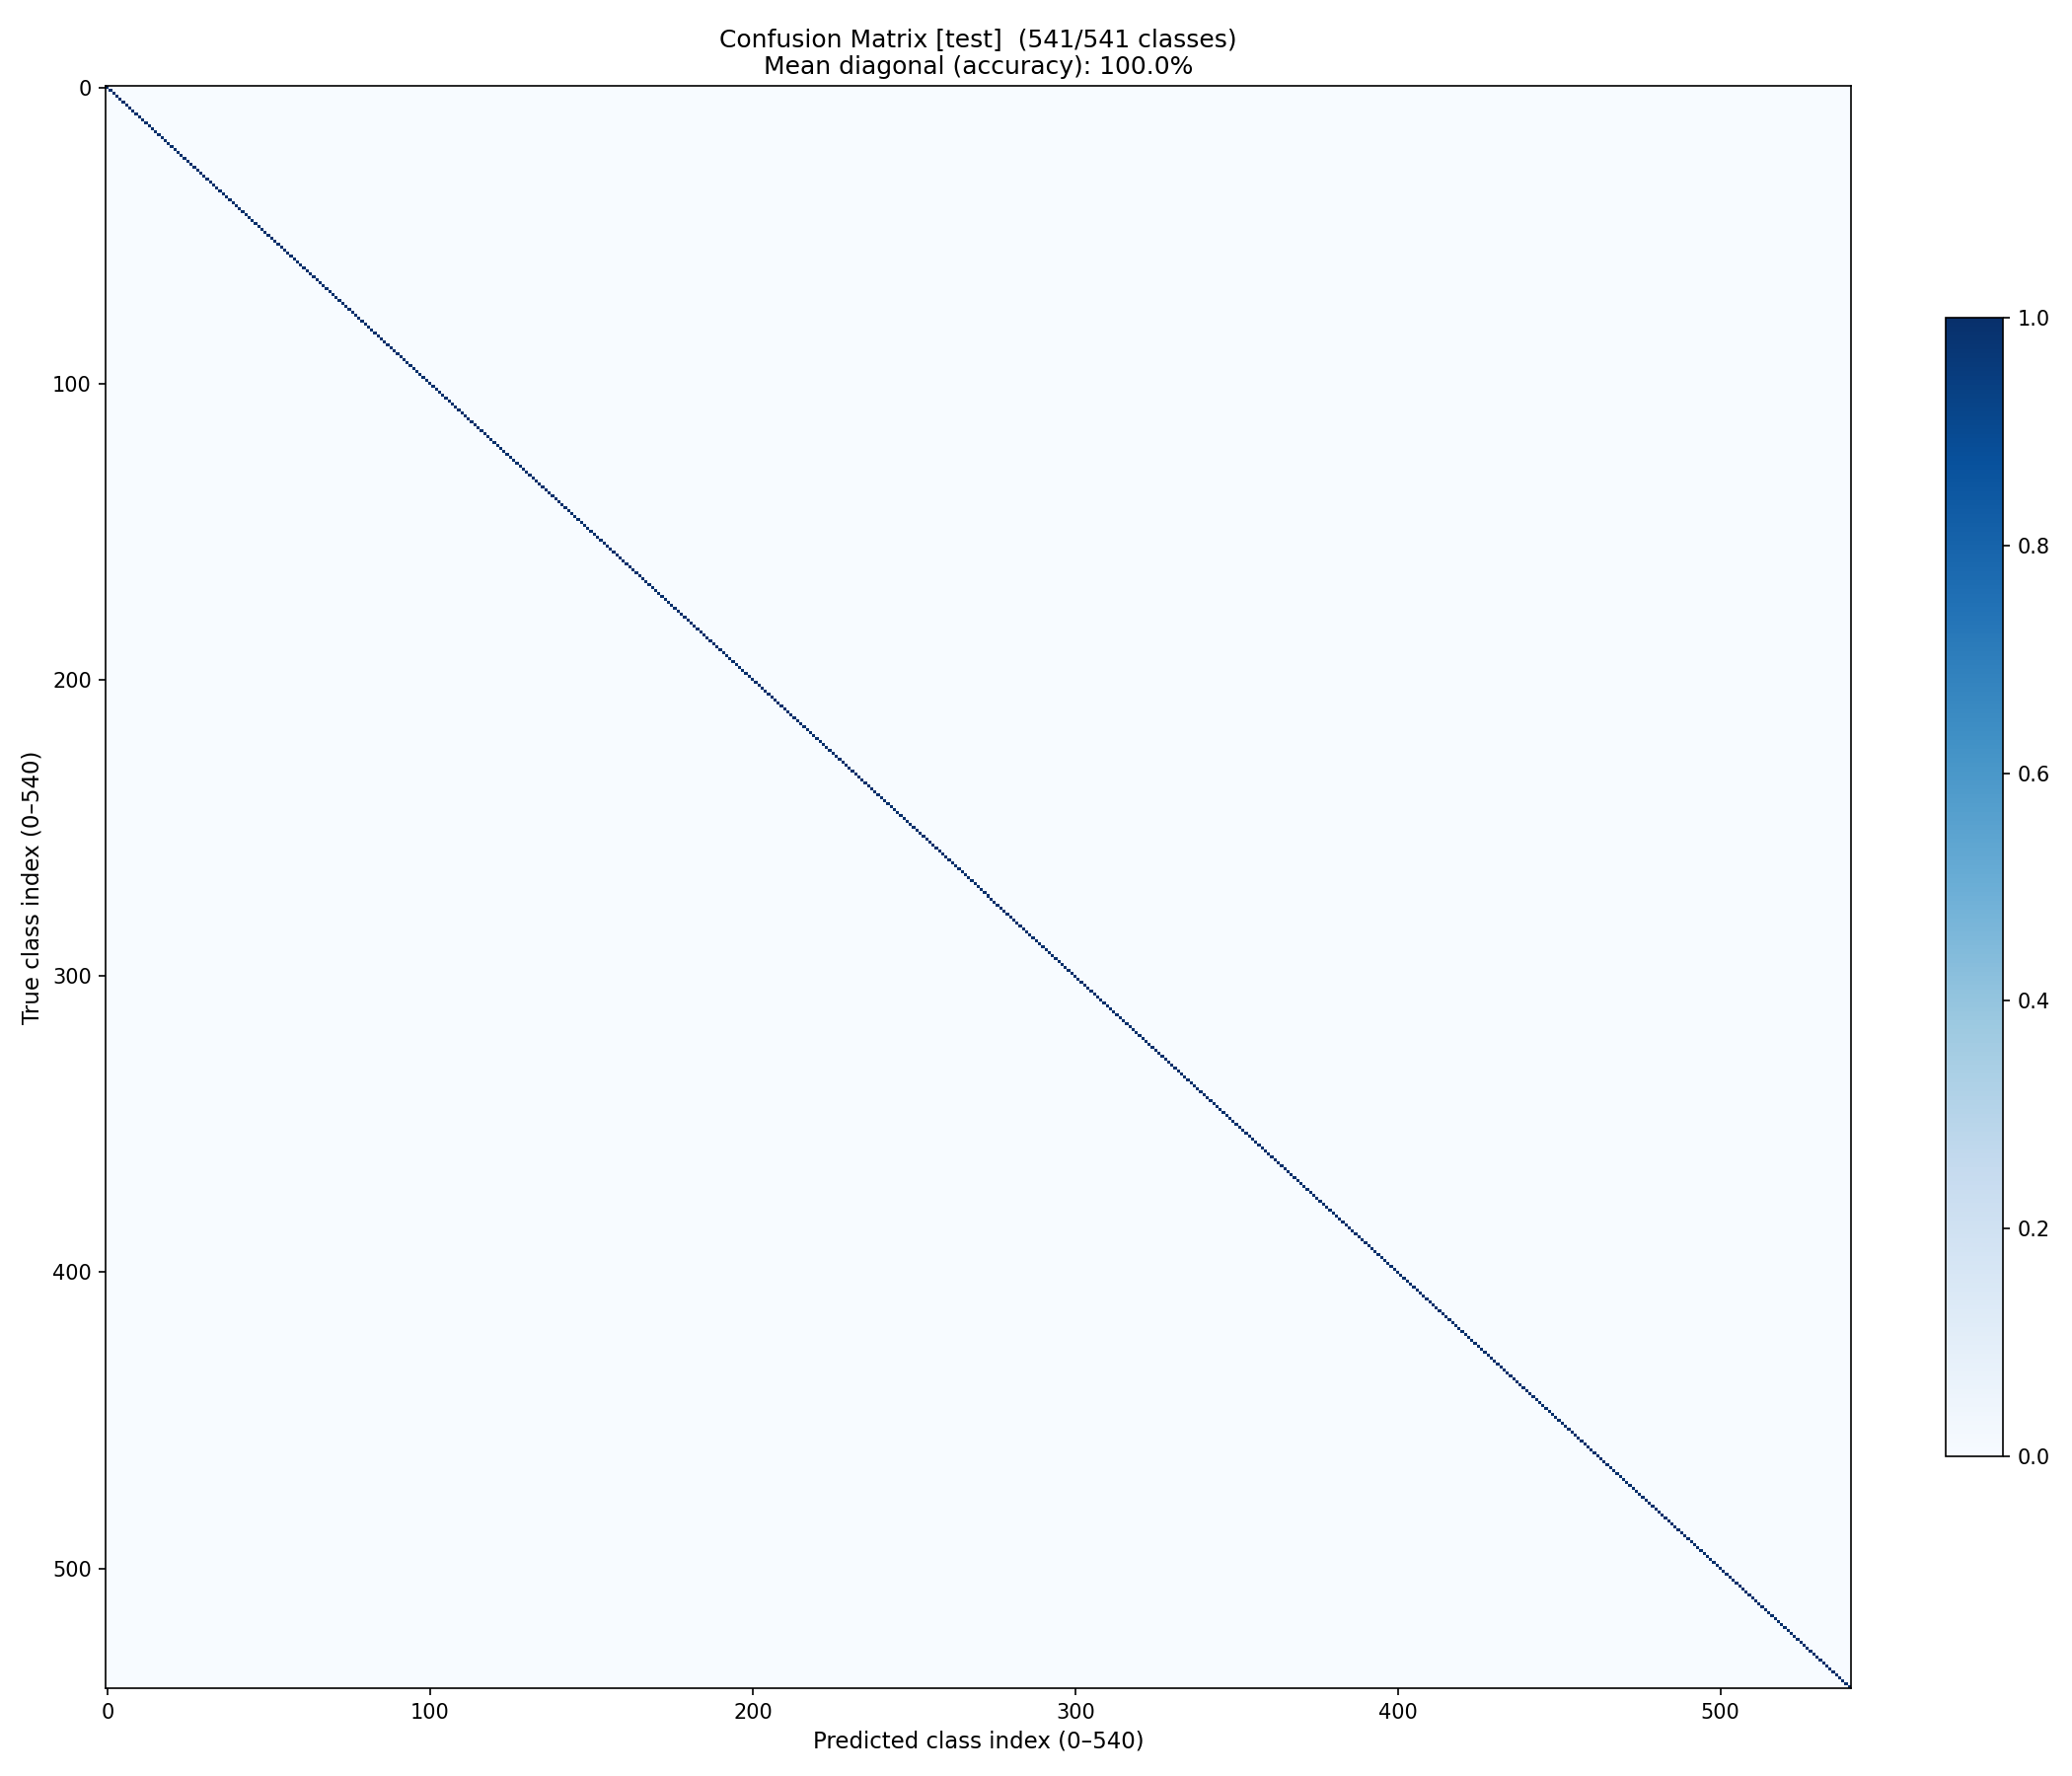

In [26]:
from IPython.display import Image, display

# Replace this path if your file is in a different subdirectory
image_path = './results/exp1_bilstm/evaluation/confusion_matrix_test.png'

display(Image(filename=image_path, width=1600, height=800))

### Exp2 - Transformer Model

In [27]:
!time bash scripts/04_train.sh transformer exp2_transformer

 Training MSL Recognition Model
 Model      : transformer
 Experiment : exp2_transformer
 Config     : config/config.yaml

 Data: train=10602, val=558, test=558 (all-class design)

[GPU]
Tesla T4, 15360 MiB, 14913 MiB, 70
Tesla T4, 15360 MiB, 14913 MiB, 32

2026-06-14 04:16:10.506207: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781410570.528538    8720 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781410570.535583    8720 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781410570.553489    8720 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W000

In [28]:
!time bash scripts/05_evaluate.sh transformer exp2_transformer

 Evaluation — transformer / exp2_transformer
 Checkpoint : results/exp2_transformer/checkpoints/best.pth
 Output dir : results/exp2_transformer/evaluation

── Validation set ──────────────────────────────────────────
2026-06-14 04:37:06 | INFO     | evaluate | Loaded checkpoint: results/exp2_transformer/checkpoints/best.pth  Model: transformer
2026-06-14 04:37:06 | INFO     | evaluate | Evaluating 558 samples from 'val' split
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
2026-06-14 04:37:06 | INFO     | evaluate | Model loaded. Evaluating 558 samples…

────────────────────────────────

In [29]:
!time bash scripts/04_train.sh stgcn exp3_stgcn

 Training MSL Recognition Model
 Model      : stgcn
 Experiment : exp3_stgcn
 Config     : config/config.yaml

 Data: train=10602, val=558, test=558 (all-class design)

[GPU]
Tesla T4, 15360 MiB, 14913 MiB, 71
Tesla T4, 15360 MiB, 14913 MiB, 32

2026-06-14 04:37:20.143728: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781411840.166298   16208 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781411840.173532   16208 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781411840.191323   16208 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781

In [30]:
!time bash scripts/05_evaluate.sh stgcn exp3_stgcn

 Evaluation — stgcn / exp3_stgcn
 Checkpoint : results/exp3_stgcn/checkpoints/best.pth
 Output dir : results/exp3_stgcn/evaluation

── Validation set ──────────────────────────────────────────
2026-06-14 07:39:42 | INFO     | evaluate | Loaded checkpoint: results/exp3_stgcn/checkpoints/best.pth  Model: stgcn
2026-06-14 07:39:42 | INFO     | evaluate | Evaluating 558 samples from 'val' split
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
2026-06-14 07:39:42 | INFO     | evaluate | Model loaded. Evaluating 558 samples…

───────────────────────────────────────────────────────
  Evaluation

### Perfromance and Training Result

In [33]:
!python src/plot_results_v2.py \
      --exp results/exp1_bilstm results/exp2_transformer results/exp3_stgcn \
      --output results/comparison_val.png \
      --output_test results/comparison_test.png

Training curves saved → results/exp1_bilstm/training_curves.png
Training curves saved → results/exp2_transformer/training_curves.png
Training curves saved → results/exp3_stgcn/training_curves.png
Val comparison chart saved → results/comparison_val.png
Test comparison chart saved → results/comparison_test.png


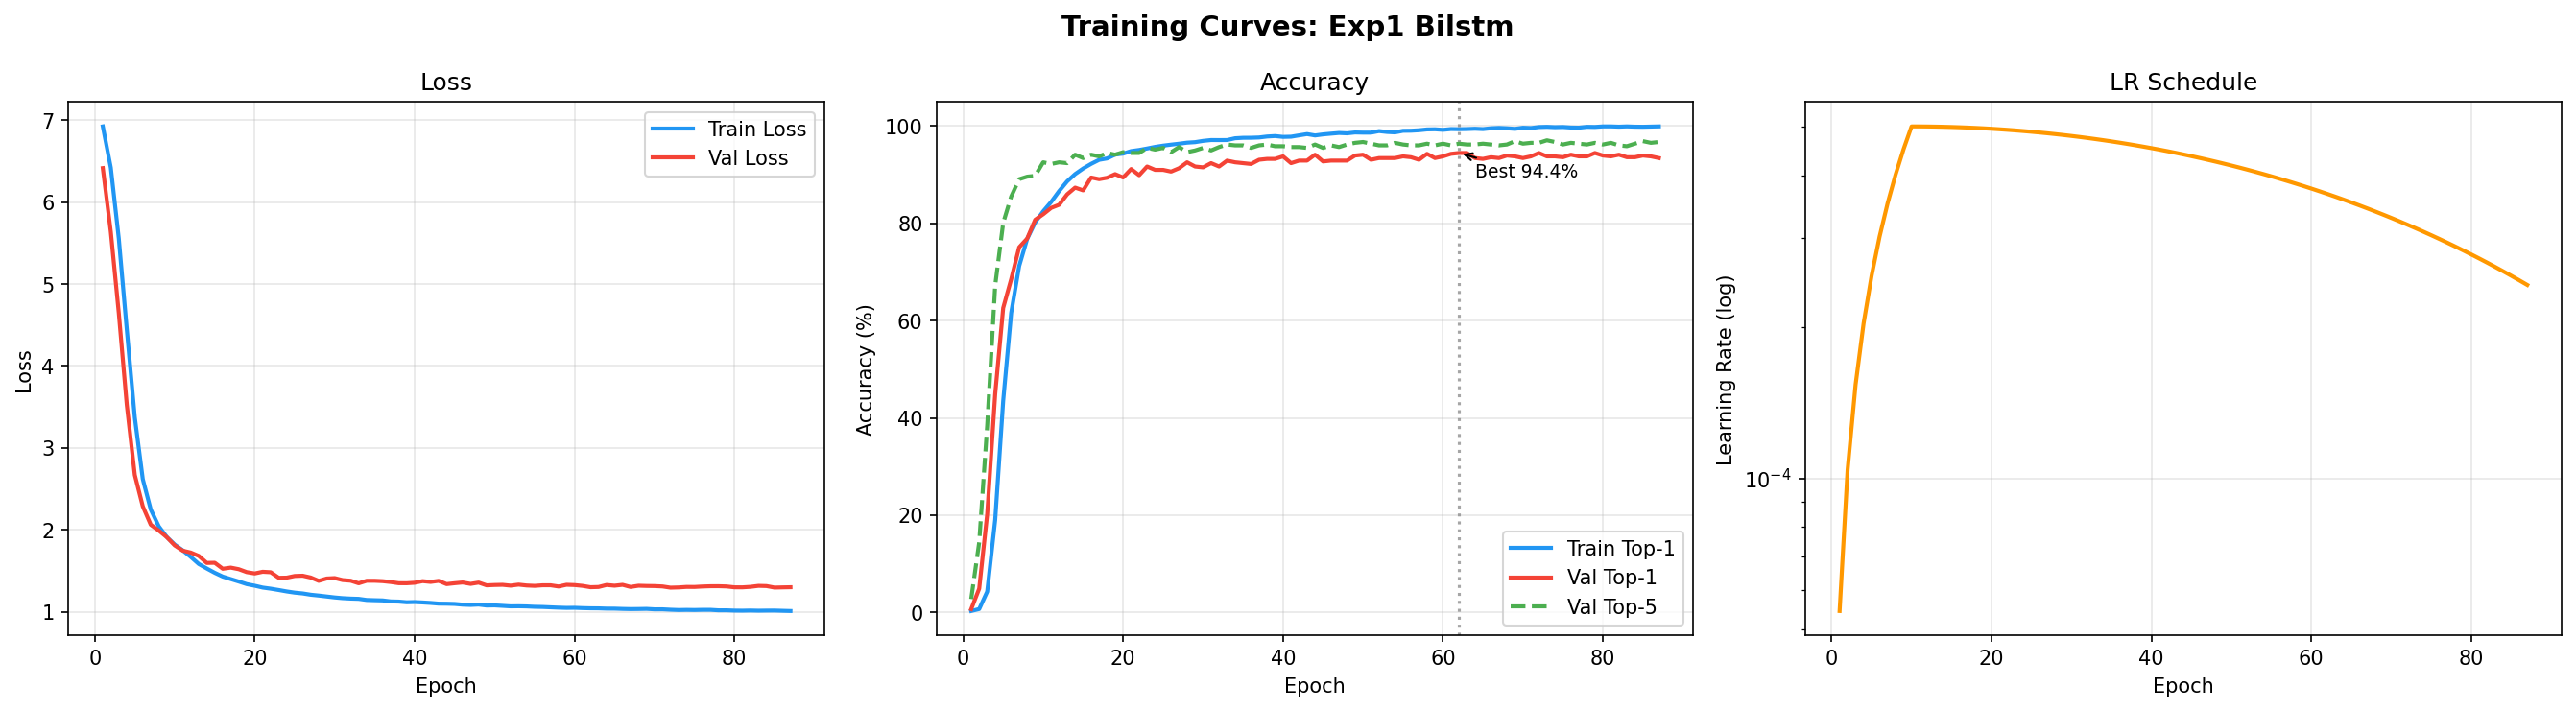

In [34]:
from IPython.display import Image, display

image_path = './results/exp1_bilstm/training_curves.png'
display(Image(filename=image_path))

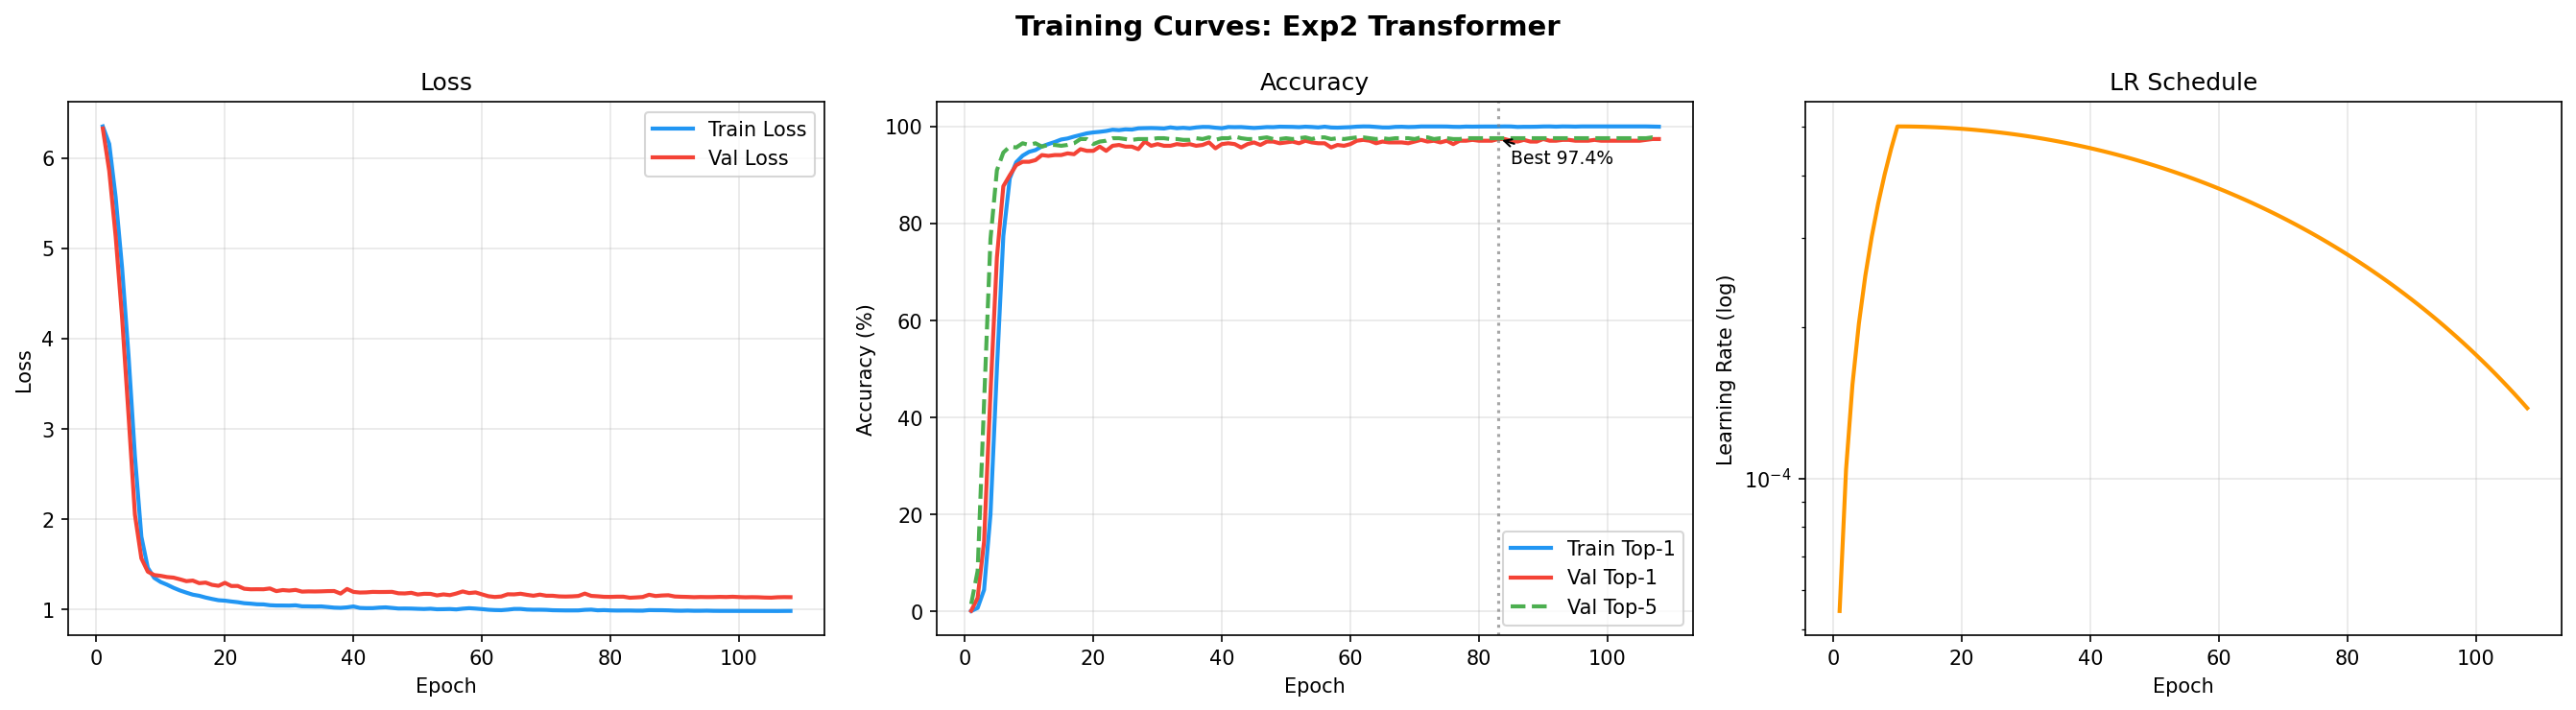

In [35]:
from IPython.display import Image, display

image_path = './results/exp2_transformer/training_curves.png'
display(Image(filename=image_path))

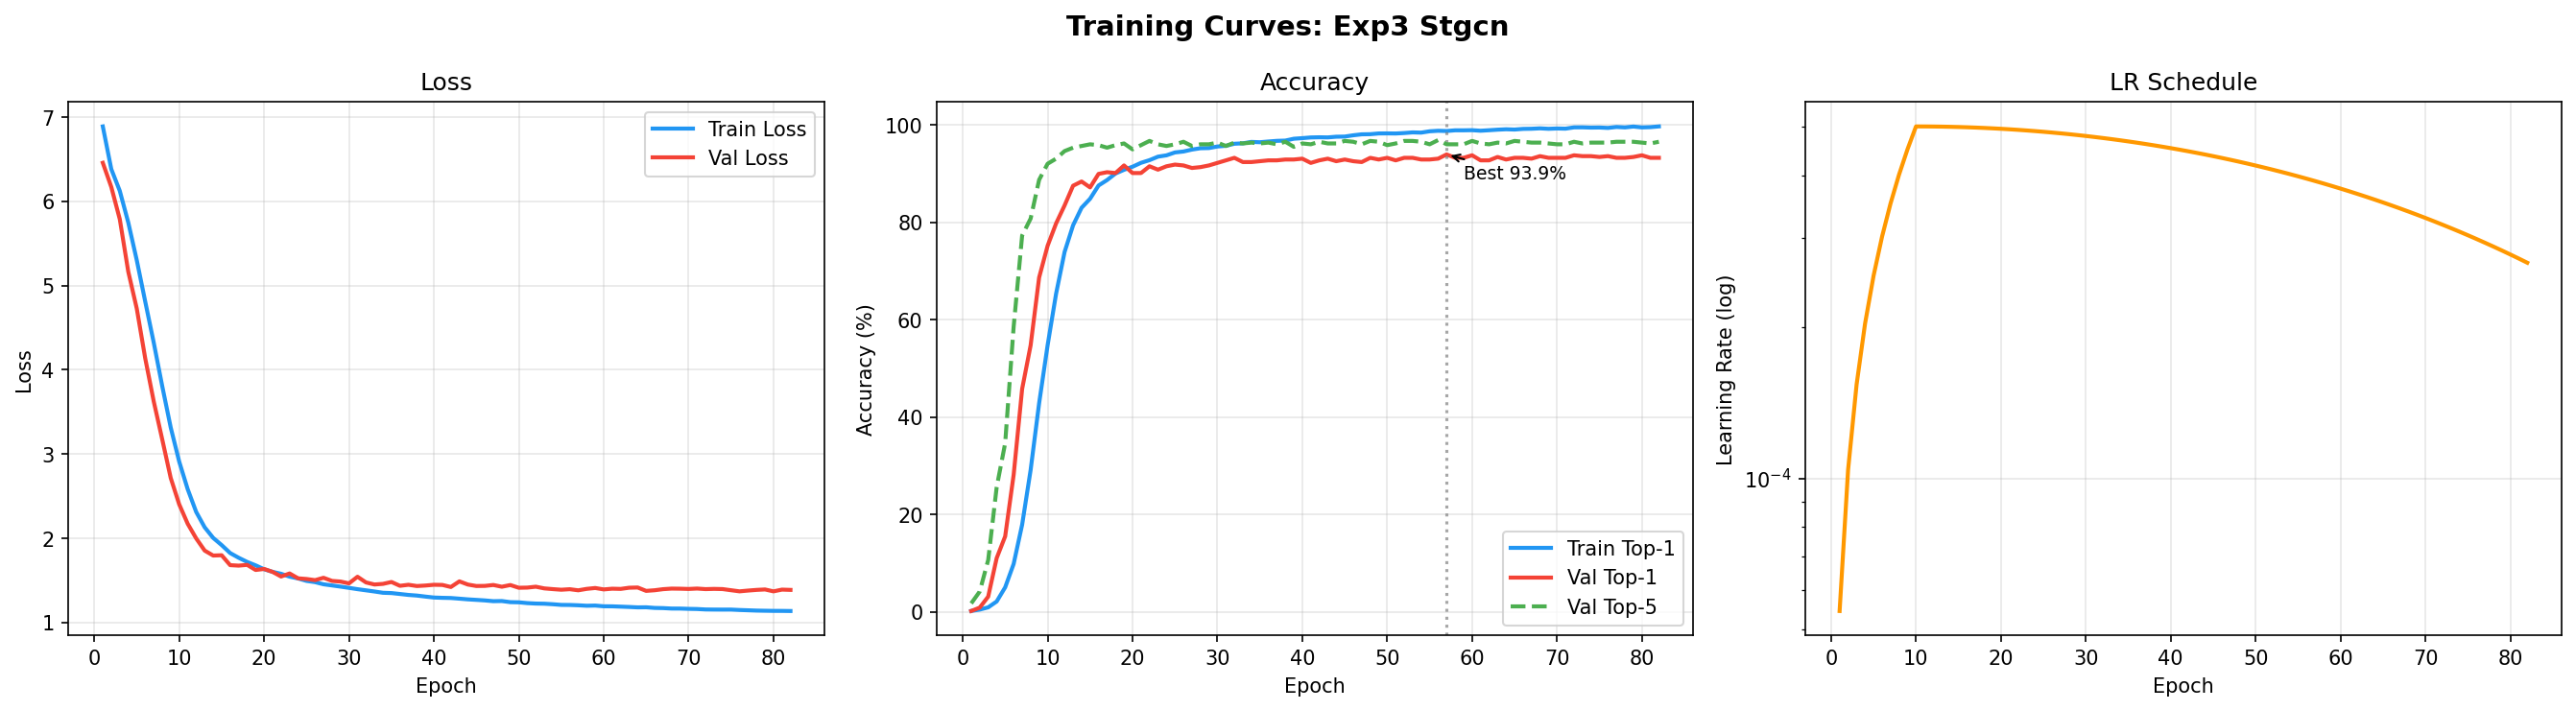

In [36]:
from IPython.display import Image, display

image_path = 'results/exp3_stgcn/training_curves.png'
display(Image(filename=image_path))

#### Model Comparison

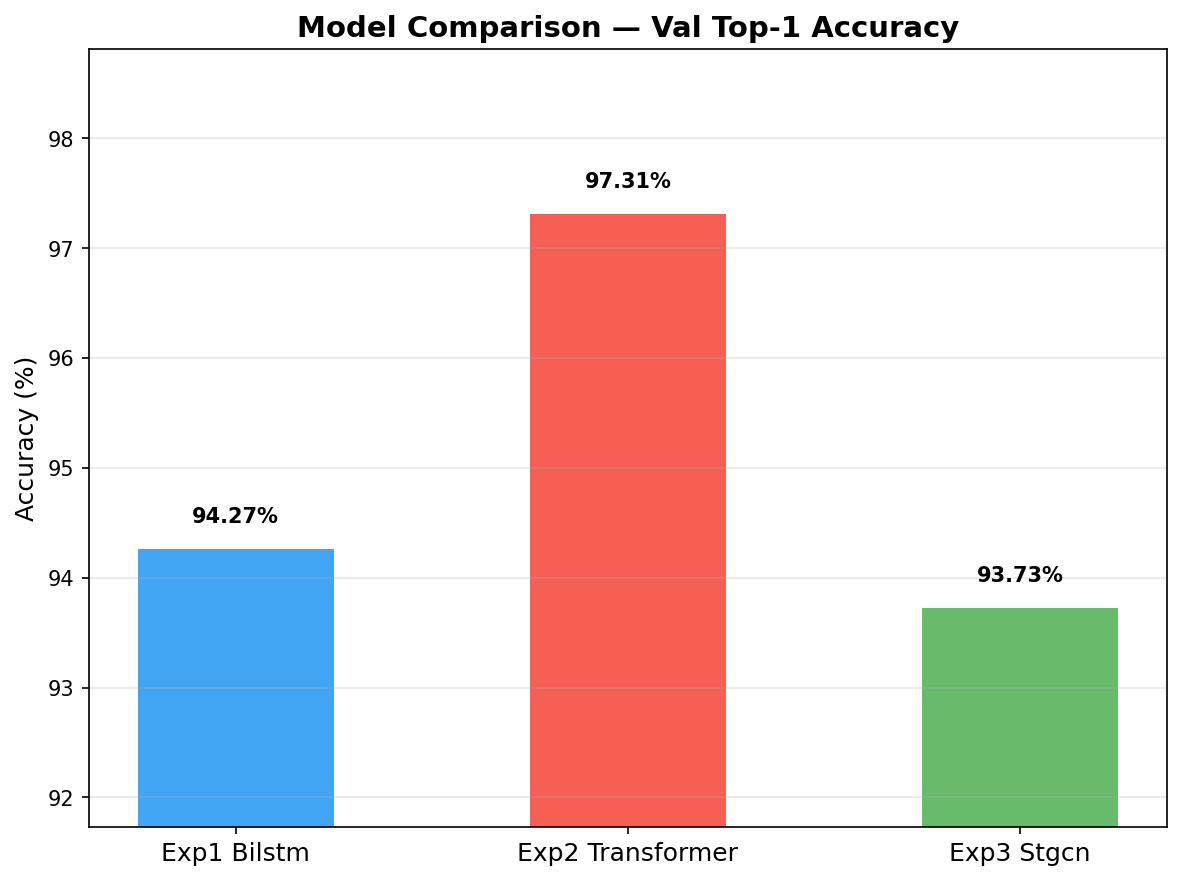

In [37]:
from IPython.display import Image, display

image_path = './results/comparison_val.png'
display(Image(filename=image_path, width=400, height=200))

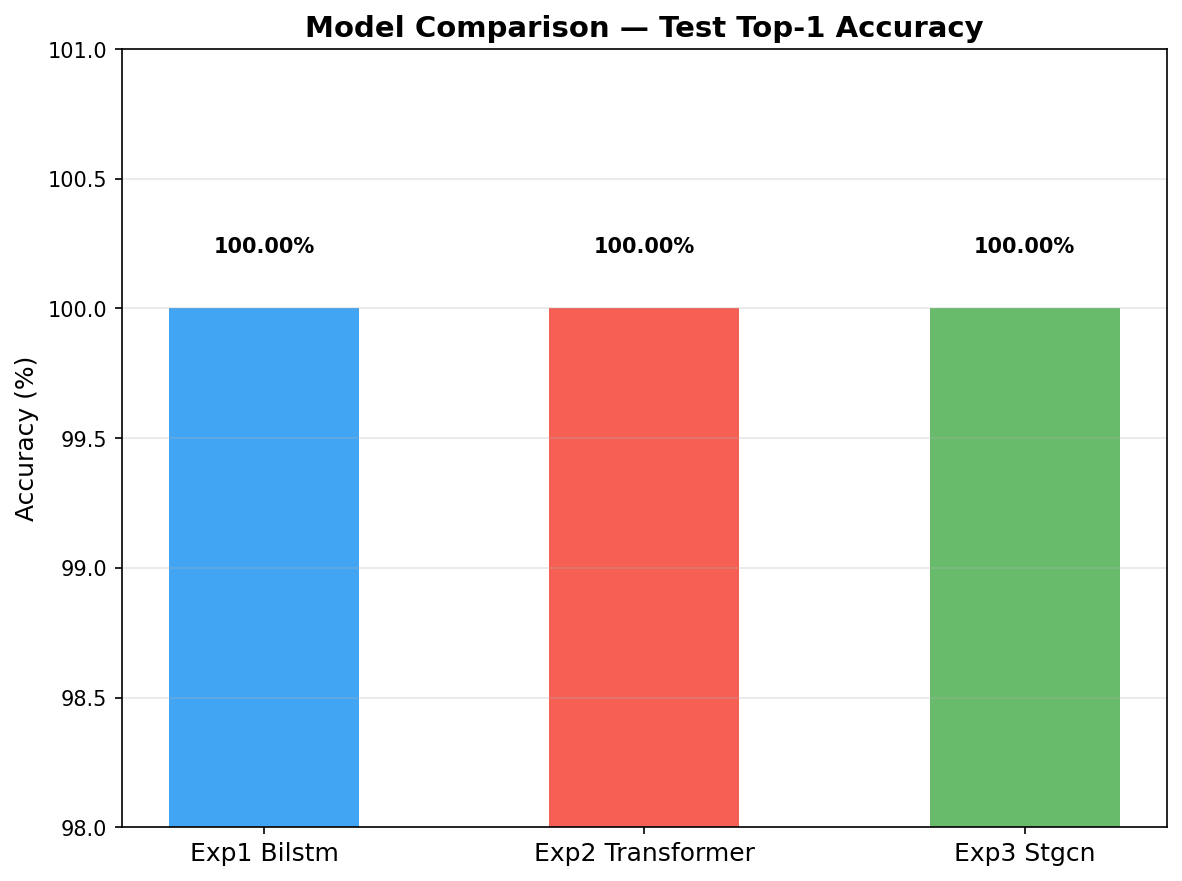

In [38]:
from IPython.display import Image, display

image_path = './results/comparison_test.png'
display(Image(filename=image_path, width=400, height=200))

In [41]:
%%writefile ./scripts/compare_results.py
#!/usr/bin/env python3
"""
compare_results.py - Print a comparison table of Bi-LSTM, Transformer, and ST-GCN
"""

import json
from pathlib import Path

def main():
    models = [
        ("Bi-LSTM",     "exp1_bilstm"),
        ("Transformer", "exp2_transformer"),
        ("ST-GCN",      "exp3_stgcn"),
    ]

    # Table Header
    # Using monospaced alignment
    header = (
        f"{'Model':<13} | "
        f"{'Val Top-1':>9} {'Val Top-5':>9} {'Val F1':>8} | "
        f"{'Test Top-1':>10} {'Test Top-5':>10} {'Test Prec':>10} {'Test Rec':>9} {'Test F1':>8}"
    )
    print("=" * len(header))
    print("          Model Performance Comparison (Myanmar Sign Language)")
    print("=" * len(header))
    print(header)
    print("─" * len(header))

    for name, exp_dir in models:
        base = Path("results") / exp_dir / "evaluation"
        val_m = base / "metrics_val.json"
        tst_m = base / "metrics_test.json"

        # Initialize with dashes in case files are missing
        val_top1 = val_top5 = val_f1 = "—"
        tst_top1 = tst_top5 = tst_prec = tst_rec = tst_f1 = "—"

        # Read Validation metrics
        if val_m.exists():
            with open(val_m, 'r') as f:
                d = json.load(f)
            val_top1 = f"{d.get('top1_accuracy', 0.0)*100:.2f}%"
            val_top5 = f"{d.get('top5_accuracy', 0.0)*100:.2f}%"
            val_f1   = f"{d.get('f1_macro', 0.0)*100:.2f}%"

        # Read Test metrics
        if tst_m.exists():
            with open(tst_m, 'r') as f:
                d = json.load(f)
            tst_top1 = f"{d.get('top1_accuracy', 0.0)*100:.2f}%"
            tst_top5 = f"{d.get('top5_accuracy', 0.0)*100:.2f}%"
            tst_prec = f"{d.get('precision_macro', 0.0)*100:.2f}%"
            tst_rec  = f"{d.get('recall_macro', 0.0)*100:.2f}%"
            tst_f1   = f"{d.get('f1_macro', 0.0)*100:.2f}%"

        row = (
            f"{name:<13} | "
            f"{val_top1:>9} {val_top5:>9} {val_f1:>8} | "
            f"{tst_top1:>10} {tst_top5:>10} {tst_prec:>10} {tst_rec:>9} {tst_f1:>8}"
        )
        print(row)

    print("=" * len(header))

if __name__ == "__main__":
    main()

Overwriting ./scripts/compare_results.py


In [42]:
!python scripts/compare_results.py

          Model Performance Comparison (Myanmar Sign Language)
Model         | Val Top-1 Val Top-5   Val F1 | Test Top-1 Test Top-5  Test Prec  Test Rec  Test F1
──────────────────────────────────────────────────────────────────────────────────────────────────
Bi-LSTM       |    94.27%    96.24%   92.42% |    100.00%    100.00%    100.00%   100.00%  100.00%
Transformer   |    97.31%    97.49%   96.30% |    100.00%    100.00%    100.00%   100.00%  100.00%
ST-GCN        |    93.73%    95.88%   92.32% |    100.00%    100.00%    100.00%   100.00%  100.00%


### Model Performance Comparison (Myanmar Sign Language)

| Model         | Val Top-1 | Val Top-5  | Val F1 | Test Top-1 | Test Top-5 | Test Prec | Test Rec |  Test F1 |
|:--------------|------------|------------|----------|------------|----------|-----------|----------|----------|
| Bi-LSTM       |    94.27%  |  96.24%  | 92.42% |    100.00%  |  100.00%  |  100.00%  | 100.00% | 100.00% |
| Transformer   |    97.31%  |  97.49%  | 96.30% |    100.00%  |  100.00%   | 100.00%  | 100.00% | 100.00% |
| ST-GCN        |    93.73%  |  95.88%  | 92.32% |    100.00%  |  100.00%  |  100.00%  | 100.00% | 100.00% |